### Surrogated Models

In [1]:
import os; WORKDIR = f"{os.getcwd()}/.."
import sys; sys.path.append(f"{WORKDIR}/libPython")
import ROOT

import torch
import torch.nn.functional as F
from torch.nn import BatchNorm1d, Sequential, ReLU, Linear, Dropout
from torch_geometric.nn import GraphNorm
from torch_geometric.nn import MessagePassing, GraphConv
from torch_geometric.nn import global_mean_pool, knn_graph
from torch_geometric.utils import dropout_edge
from torch_geometric.loader import DataLoader
from torch.utils.tensorboard import SummaryWriter
from sklearn.utils import shuffle
from DataManager import rtfileToDataList, GraphDataset
from Models import ParticleNet

import matplotlib.pyplot as plt
import networkx as nx
from tqdm import tqdm

Welcome to JupyROOT 6.28/04


In [2]:
maxSize = -1
SIGNAL = "MHc-130_MA-90"
BACKGROUND = "ttZ"
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"@@@@ Using DEVICE {DEVICE}")

@@@@ Using DEVICE cuda


In [3]:
# load dataset
# load dataset
rtSig = ROOT.TFile.Open(f"{WORKDIR}/DATA/{SIGNAL}.root")
rtBkg = ROOT.TFile.Open(f"{WORKDIR}/DATA/{BACKGROUND}.root")

sigDataList = shuffle(rtfileToDataList(rtSig, isSignal=True,  maxSize=maxSize), random_state=42)
bkgDataList = shuffle(rtfileToDataList(rtBkg, isSignal=False, maxSize=maxSize), random_state=42)
dataList = shuffle(sigDataList+bkgDataList, random_state=42)

trainset = GraphDataset(dataList[:int(len(dataList)*0.6)])
validset = GraphDataset(dataList[int(len(dataList)*0.6):int(len(dataList)*0.7)])
testset  = GraphDataset(dataList[int(len(dataList)*0.7):])

trainLoader = DataLoader(trainset, batch_size=512, pin_memory=True, shuffle=True)
validLoader = DataLoader(validset, batch_size=512, pin_memory=True, shuffle=False)
testLoader = DataLoader(testset, batch_size=512, pin_memory=True, shuffle=False)

# reload dataset for visualization
sigDataList = shuffle(rtfileToDataList(rtSig, isSignal=True, returnParticleTypes=True, maxSize=100), random_state=42); rtSig.Close()
bkgDataList = shuffle(rtfileToDataList(rtBkg, isSignal=False, returnParticleTypes=True, maxSize=100), random_state=42); rtBkg.Close()

@@@@ no. of dataList ends with 105000
@@@@ no. of dataList ends with 105000
@@@@ no. of dataList ends with 100
@@@@ no. of dataList ends with 100


In [8]:
# Define surrogated model
class EdgeConv(MessagePassing):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__(aggr="mean")
        self.mlp = Sequential(
                Linear(2*in_channels, hidden_channels), ReLU(), BatchNorm1d(hidden_channels), Dropout(0.4),
                Linear(out_channels, hidden_channels), ReLU(), BatchNorm1d(hidden_channels), Dropout(0.4),
                Linear(out_channels, hidden_channels), ReLU(), BatchNorm1d(hidden_channels), Dropout(0.4)
                )

    def forward(self, x, edge_index, batch=None):
        return self.propagate(edge_index, x=x, batch=batch)

    def message(self, x_i, x_j):
        tmp = torch.cat([x_i, x_j - x_i], dim=1)
        return self.mlp(tmp)


class DynamicEdgeConv(EdgeConv):
    def __init__(self, in_channels, hidden_channels, out_channels, training, k=4):
        super().__init__(in_channels, hidden_channels, out_channels)
        self.shortcut = Sequential(Linear(in_channels, out_channels), ReLU())
        self.training = training
        #self.dropout_p = dropout_p
        self.k = k

    def forward(self, x, edge_index=None, batch=None):
        if edge_index is None: edge_index = knn_graph(x, self.k, batch, loop=False, flow=self.flow)
        #edge_index, _ = dropout_edge(edge_index, p=self.dropout_p, training=self.training)
        out = super().forward(x, edge_index, batch=batch)
        out += self.shortcut(x)
        return out
    
class GraphNet(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GraphNet, self).__init__()
        self.gn0 = GraphNorm(in_channels)
        self.bn0 = BatchNorm1d(hidden_channels)
        self.conv1 = GraphConv(in_channels, hidden_channels)
        self.conv2 = DynamicEdgeConv(hidden_channels, hidden_channels, hidden_channels, training=self.training, k=4)
        self.conv3 = DynamicEdgeConv(hidden_channels, hidden_channels, hidden_channels, training=self.training, k=4)
        self.dense1 = Linear(hidden_channels, hidden_channels)
        self.dense2 = Linear(hidden_channels, hidden_channels)
        self.output = Linear(hidden_channels, out_channels)
        
    def forward(self, x, edge_index, edge_weight=None, batch=None):
        # convolution layers
        x = self.gn0(x, batch=batch)
        conv1 = F.elu(self.conv1(x, edge_index, edge_weight))
        conv2 = self.conv2(conv1, edge_index, batch=batch)
        conv3 = self.conv3(conv2, edge_index, batch=batch)
        x = conv1+conv2+conv3
        
        # readout layers
        x = global_mean_pool(x, batch=batch)
        
        # dense layers
        x = self.bn0(x)
        x = F.alpha_dropout(x, p=0.4)
        x = F.selu(self.dense1(x))
        x = F.alpha_dropout(x, p=0.4)
        x = F.selu(self.dense2(x))
        x = self.output(x)

        return F.log_softmax(x, dim=1)

In [5]:
def train(model, optimizer, scheduler, trainLoader):
    model.train()
    
    for data in trainLoader:
        data = data.to(DEVICE)
        out = model(data.x, data.edge_index, batch=data.batch)
        optimizer.zero_grad()
        loss = F.cross_entropy(out, data.y)
        loss.backward()
        optimizer.step()
    scheduler.step()

def test(model, loader):
    model.eval()
    loss = 0.
    correct = 0
    with torch.no_grad():
        for data in loader:
            data = data.to(DEVICE)
            out = model(data.x, data.edge_index, batch=data.batch)
            pred = out.argmax(dim=1)
            loss += F.cross_entropy(out, data.y).sum().item()
            correct += pred.eq(data.y).sum().item()
    loss /= len(loader.dataset)
    correct /= len(loader.dataset)
    return (loss, correct)

In [6]:
# first model: edge_dropout = 0.05
model = ParticleNet(in_channels=8, hidden_channels=64, out_channels=2)
model.load_state_dict(torch.load("./models/ParticleNet-0.05.pt"))
model.to("cpu")

model.eval()
newTrainList = []
with torch.no_grad():
    for data in tqdm(trainset):
        out = model(data.x, data.edge_index)
        newData = data.clone()
        newData.y = out.argmax(dim=1)
        newTrainList.append(newData)

newValidList = []
with torch.no_grad():
    for data in tqdm(validset):
        out = model(data.x, data.edge_index)
        newData = data.clone()
        newData.y = out.argmax(dim=1)
        newValidList.append(newData)
        
newTestList = []
with torch.no_grad():
    for data in tqdm(testset):
        out = model(data.x, data.edge_index)
        newData = data.clone()
        newData.y = out.argmax(dim=1)
        newTestList.append(newData)
        
newTrainSet, newValidSet, newTestSet = GraphDataset(newTrainList), GraphDataset(newValidList), GraphDataset(newTestList)
newTrainLoader = DataLoader(newTrainSet, batch_size=512, pin_memory=True, shuffle=True)
newValidLoader = DataLoader(newValidSet, batch_size=512, pin_memory=True, shuffle=False)
newTestLoader = DataLoader(newTestSet, batch_size=512, pin_memory=True, shuffle=False)

100%|██████████| 63000/63000 [01:25<00:00, 738.86it/s]


In [9]:
# train surrgated model
model = GraphNet(in_channels=8, hidden_channels=64, out_channels=2).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)
scheduler = torch.optim.lr_scheduler.CyclicLR(optimizer, base_lr=0.0005, max_lr=0.01,
                                                         step_size_up=3, step_size_down=5,
                                                         cycle_momentum=False)
writer = SummaryWriter("./runs/ex6/Surrogated_0p05")

for epoch in range(30):
    train(model, optimizer, scheduler, newTrainLoader)
    trainLoss, trainAcc = test(model, newTrainLoader)
    validLoss, validAcc = test(model, newValidLoader)
    writer.add_scalar("Loss/train", trainLoss, epoch)
    writer.add_scalar("Loss/valid", validLoss, epoch)
    writer.add_scalar("Acc/train", trainAcc, epoch)
    writer.add_scalar("Acc/valid", validAcc, epoch)
    
    print(f"[EPOCH {epoch}]\tTrain Acc: {trainAcc*100:.2f}\tTrain Loss: {trainLoss:.4e}")
    print(f"[EPOCH {epoch}]\tValid Acc: {validAcc*100:.2f}\tValid Loss: {validLoss:.4e}\n")

torch.save(model.state_dict(), "./models/Surrogated-0.05.pt")  
writer.flush()
writer.close()

[EPOCH 0]	Train Acc: 60.68	Train Loss: 1.2890e-03
[EPOCH 0]	Valid Acc: 60.70	Valid Loss: 1.3145e-03

[EPOCH 1]	Train Acc: 75.96	Train Loss: 9.5867e-04
[EPOCH 1]	Valid Acc: 75.93	Valid Loss: 9.8509e-04

[EPOCH 2]	Train Acc: 79.92	Train Loss: 8.3536e-04
[EPOCH 2]	Valid Acc: 79.98	Valid Loss: 8.5967e-04

[EPOCH 3]	Train Acc: 79.78	Train Loss: 8.3784e-04
[EPOCH 3]	Valid Acc: 79.67	Valid Loss: 8.6611e-04

[EPOCH 4]	Train Acc: 82.30	Train Loss: 7.4647e-04
[EPOCH 4]	Valid Acc: 81.92	Valid Loss: 7.8317e-04

[EPOCH 5]	Train Acc: 85.93	Train Loss: 6.1563e-04
[EPOCH 5]	Valid Acc: 85.46	Valid Loss: 6.4962e-04

[EPOCH 6]	Train Acc: 86.35	Train Loss: 5.9272e-04
[EPOCH 6]	Valid Acc: 86.14	Valid Loss: 6.2099e-04

[EPOCH 7]	Train Acc: 87.02	Train Loss: 5.6825e-04
[EPOCH 7]	Valid Acc: 86.33	Valid Loss: 6.0359e-04

[EPOCH 8]	Train Acc: 88.18	Train Loss: 5.2028e-04
[EPOCH 8]	Valid Acc: 87.68	Valid Loss: 5.6001e-04

[EPOCH 9]	Train Acc: 87.09	Train Loss: 5.6393e-04
[EPOCH 9]	Valid Acc: 86.61	Valid Loss: 5.

In [10]:
# second model: edge_dropout = 0.2
model = ParticleNet(in_channels=8, hidden_channels=64, out_channels=2)
model.load_state_dict(torch.load("./models/ParticleNet-0.2.pt"))
model.to("cpu")

model.eval()
newTrainList = []
with torch.no_grad():
    for data in tqdm(trainset):
        out = model(data.x, data.edge_index)
        newData = data.clone()
        newData.y = out.argmax(dim=1)
        newTrainList.append(newData)

newValidList = []
with torch.no_grad():
    for data in tqdm(validset):
        out = model(data.x, data.edge_index)
        newData = data.clone()
        newData.y = out.argmax(dim=1)
        newValidList.append(newData)
        
newTestList = []
with torch.no_grad():
    for data in tqdm(testset):
        out = model(data.x, data.edge_index)
        newData = data.clone()
        newData.y = out.argmax(dim=1)
        newTestList.append(newData)
        
newTrainSet, newValidSet, newTestSet = GraphDataset(newTrainList), GraphDataset(newValidList), GraphDataset(newTestList)
newTrainLoader = DataLoader(newTrainSet, batch_size=512, pin_memory=True, shuffle=True)
newValidLoader = DataLoader(newValidSet, batch_size=512, pin_memory=True, shuffle=False)
newTestLoader = DataLoader(newTestSet, batch_size=512, pin_memory=True, shuffle=False)

100%|██████████| 63000/63000 [01:18<00:00, 802.74it/s]


In [11]:
# train surrgated model
model = GraphNet(in_channels=8, hidden_channels=64, out_channels=2).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)
scheduler = torch.optim.lr_scheduler.CyclicLR(optimizer, base_lr=0.0005, max_lr=0.01,
                                                         step_size_up=3, step_size_down=5,
                                                         cycle_momentum=False)
writer = SummaryWriter("./runs/ex6/Surrogated_0p2")

for epoch in range(30):
    train(model, optimizer, scheduler, newTrainLoader)
    trainLoss, trainAcc = test(model, newTrainLoader)
    validLoss, validAcc = test(model, newValidLoader)
    writer.add_scalar("Loss/train", trainLoss, epoch)
    writer.add_scalar("Loss/valid", validLoss, epoch)
    writer.add_scalar("Acc/train", trainAcc, epoch)
    writer.add_scalar("Acc/valid", validAcc, epoch)
    
    print(f"[EPOCH {epoch}]\tTrain Acc: {trainAcc*100:.2f}\tTrain Loss: {trainLoss:.4e}")
    print(f"[EPOCH {epoch}]\tValid Acc: {validAcc*100:.2f}\tValid Loss: {validLoss:.4e}\n")

torch.save(model.state_dict(), "./models/Surrogated-0.2.pt")  
writer.flush()
writer.close()

[EPOCH 0]	Train Acc: 58.05	Train Loss: 1.3290e-03
[EPOCH 0]	Valid Acc: 58.00	Valid Loss: 1.3568e-03

[EPOCH 1]	Train Acc: 76.42	Train Loss: 9.3328e-04
[EPOCH 1]	Valid Acc: 75.94	Valid Loss: 9.6158e-04

[EPOCH 2]	Train Acc: 81.00	Train Loss: 7.9705e-04
[EPOCH 2]	Valid Acc: 80.98	Valid Loss: 8.1367e-04

[EPOCH 3]	Train Acc: 82.61	Train Loss: 7.4102e-04
[EPOCH 3]	Valid Acc: 82.29	Valid Loss: 7.6680e-04

[EPOCH 4]	Train Acc: 84.77	Train Loss: 6.5792e-04
[EPOCH 4]	Valid Acc: 84.65	Valid Loss: 6.8424e-04

[EPOCH 5]	Train Acc: 86.26	Train Loss: 5.9777e-04
[EPOCH 5]	Valid Acc: 85.98	Valid Loss: 6.2687e-04

[EPOCH 6]	Train Acc: 86.60	Train Loss: 5.8409e-04
[EPOCH 6]	Valid Acc: 86.12	Valid Loss: 6.2314e-04

[EPOCH 7]	Train Acc: 87.65	Train Loss: 5.4437e-04
[EPOCH 7]	Valid Acc: 87.20	Valid Loss: 5.8326e-04

[EPOCH 8]	Train Acc: 88.44	Train Loss: 5.1434e-04
[EPOCH 8]	Valid Acc: 87.62	Valid Loss: 5.5876e-04

[EPOCH 9]	Train Acc: 87.69	Train Loss: 5.4295e-04
[EPOCH 9]	Valid Acc: 86.90	Valid Loss: 5.

In [42]:
from captum.attr import IntegratedGradients
import numpy as np

data = sigDataList[3]

In [43]:
model = GraphNet(in_channels=8, hidden_channels=64, out_channels=2)
model.load_state_dict(torch.load("./models/Surrogated-0.05.pt"))
model.to("cpu")
model.eval()
def model_forward(edge_mask, data):
    batch = torch.zeros(data.x.shape[0], dtype=int).to("cpu")
    out = model(data.x, data.edge_index, edge_mask, batch)
    return out

input_mask = torch.ones(data.edge_index.shape[1]).requires_grad_(True)
ig = IntegratedGradients(model_forward)
mask = ig.attribute(input_mask, target=1, additional_forward_args=(data,), internal_batch_size=data.edge_index.shape[1])
#saliency = Saliency(model_forward)
#mask = saliency.attribute(input_mask, target=1, additional_forward_args=(data,))
edge_mask = np.abs(mask.detach().numpy())
edge_mask = edge_mask / edge_mask.sum()

edge_mask_dict = {}
for u, v, attr in zip(*data.edge_index.numpy(), edge_mask):
    if u > v: u, v = v, u
    edge_mask_dict[(u, v)] = attr
print(edge_mask_dict)

{(0, 1): 0.07234760246052364, (0, 2): 0.051479380150258706, (0, 3): 0.048850376378455185, (0, 4): 0.0006196097565537388, (0, 5): 0.010873188908320364, (0, 6): 0.026061681118960043, (1, 2): 0.04908121873402298, (1, 3): 0.05227321280232007, (1, 4): 0.007577326131670473, (1, 5): 0.008954201668322427, (1, 6): 0.03614169987297147, (2, 3): 0.014113456903646352, (2, 4): 0.06189328492486087, (2, 5): 0.00873715900724802, (2, 6): 0.02016557534149068, (3, 4): 0.00811793710249391, (3, 5): 0.004444086847473299, (3, 6): 0.015505412440111804, (4, 5): 0.01417169767130318, (4, 6): 0.018475937366091443, (5, 6): 0.02230496440052003}


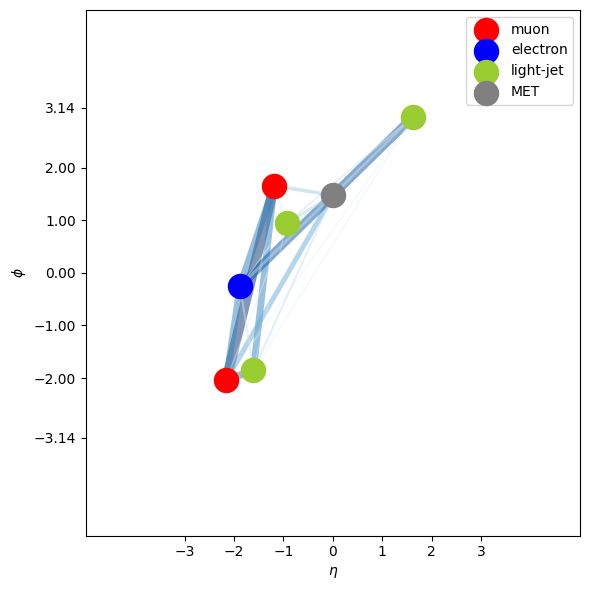

In [44]:
G = nx.Graph()
positions = {}
muons = []
electrons = []
jets = []
bjets = []
METv = []
for i, features in enumerate(data.x):
    thisParticle = ROOT.TLorentzVector()
    thisParticle.SetPxPyPzE(features[1], features[2], features[3], features[0])
    positions[i] = (thisParticle.Eta(), thisParticle.Phi())
for i, particleType in enumerate(data.particleTypes):
    if particleType == "muon": muons.append(i)
    if particleType == "electron": electrons.append(i)
    if particleType == "light-jet": jets.append(i)
    if particleType == "heavy-jet": bjets.append(i)
    if particleType == "METv": METv.append(i)
G.add_nodes_from(positions.keys())
G.add_edges_from(edge_mask_dict.keys())
edge_color = [edge_mask_dict[(u, v)] for u, v, in G.edges()]
widths = [x*100 for x in edge_color]

plt.figure(figsize=(6, 6))
nx.draw_networkx_nodes(G, positions, nodelist=muons, node_color="red", label="muon")
nx.draw_networkx_nodes(G, positions, nodelist=electrons, node_color="blue", label="electron")
nx.draw_networkx_nodes(G, positions, nodelist=jets, node_color="yellowgreen", label="light-jet")
nx.draw_networkx_nodes(G, positions, nodelist=bjets, node_color="green", label="heavy-jet")
nx.draw_networkx_nodes(G, positions, nodelist=METv, node_color="gray", label="MET")
nx.draw_networkx_edges(G, positions, edgelist=edge_mask_dict.keys(), edge_color=edge_color, alpha=0.5, width=widths, edge_cmap=plt.cm.Blues)
plt.legend(loc="upper right")
plt.xlabel(r"$\eta$")
plt.ylabel(r"$\phi$")
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.xticks([-3., -2., -1., 0., 1., 2., 3])
plt.yticks([-3.14, -2., -1., 0., 1., 2., 3.14])
plt.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)
plt.tight_layout()
plt.show()

In [45]:
model = GraphNet(in_channels=8, hidden_channels=64, out_channels=2)
model.load_state_dict(torch.load("./models/Surrogated-0.2.pt"))
model.to("cpu")
model.eval()
def model_forward(edge_mask, data):
    batch = torch.zeros(data.x.shape[0], dtype=int).to("cpu")
    out = model(data.x, data.edge_index, edge_mask, batch)
    return out

input_mask = torch.ones(data.edge_index.shape[1]).requires_grad_(True)
ig = IntegratedGradients(model_forward)
mask = ig.attribute(input_mask, target=1, additional_forward_args=(data,), internal_batch_size=data.edge_index.shape[1])
#saliency = Saliency(model_forward)
#mask = saliency.attribute(input_mask, target=1, additional_forward_args=(data,))
edge_mask = np.abs(mask.detach().numpy())
edge_mask = edge_mask / edge_mask.sum()

edge_mask_dict = {}
for u, v, attr in zip(*data.edge_index.numpy(), edge_mask):
    if u > v: u, v = v, u
    edge_mask_dict[(u, v)] = attr
print(edge_mask_dict)

{(0, 1): 0.0024924119280320322, (0, 2): 0.017277512295306205, (0, 3): 0.06429727684092591, (0, 4): 0.013741985997357601, (0, 5): 0.017649648366351238, (0, 6): 0.0556806924264769, (1, 2): 0.009097851331248213, (1, 3): 0.031523164145519214, (1, 4): 0.00911020950947362, (1, 5): 0.0041028471657584805, (1, 6): 0.03598355242740563, (2, 3): 0.010552607965418093, (2, 4): 0.026973425327848015, (2, 5): 0.01321611625919388, (2, 6): 0.026023309785971165, (3, 4): 0.017661733957463694, (3, 5): 0.0036671053201613926, (3, 6): 0.0170024949789805, (4, 5): 0.012567506079441121, (4, 6): 0.015077040226139489, (5, 6): 0.004505463135894433}


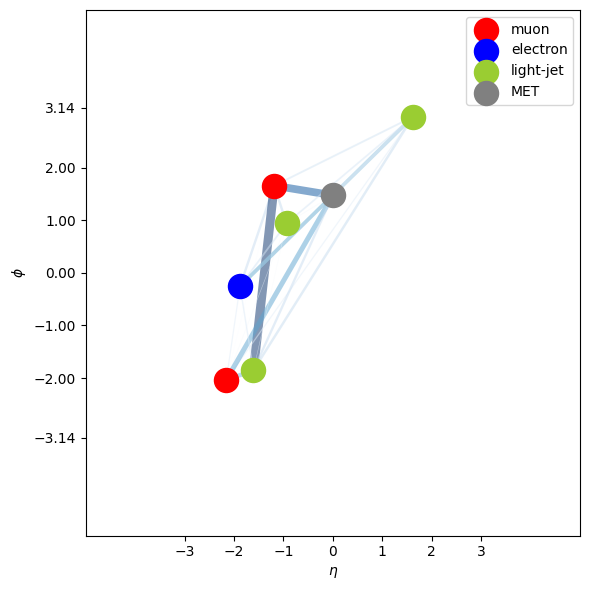

In [46]:
G = nx.Graph()
positions = {}
muons = []
electrons = []
jets = []
bjets = []
METv = []
for i, features in enumerate(data.x):
    thisParticle = ROOT.TLorentzVector()
    thisParticle.SetPxPyPzE(features[1], features[2], features[3], features[0])
    positions[i] = (thisParticle.Eta(), thisParticle.Phi())
for i, particleType in enumerate(data.particleTypes):
    if particleType == "muon": muons.append(i)
    if particleType == "electron": electrons.append(i)
    if particleType == "light-jet": jets.append(i)
    if particleType == "heavy-jet": bjets.append(i)
    if particleType == "METv": METv.append(i)
G.add_nodes_from(positions.keys())
G.add_edges_from(edge_mask_dict.keys())
edge_color = [edge_mask_dict[(u, v)] for u, v, in G.edges()]
widths = [x*100 for x in edge_color]

plt.figure(figsize=(6, 6))
nx.draw_networkx_nodes(G, positions, nodelist=muons, node_color="red", label="muon")
nx.draw_networkx_nodes(G, positions, nodelist=electrons, node_color="blue", label="electron")
nx.draw_networkx_nodes(G, positions, nodelist=jets, node_color="yellowgreen", label="light-jet")
nx.draw_networkx_nodes(G, positions, nodelist=bjets, node_color="green", label="heavy-jet")
nx.draw_networkx_nodes(G, positions, nodelist=METv, node_color="gray", label="MET")
nx.draw_networkx_edges(G, positions, edgelist=edge_mask_dict.keys(), edge_color=edge_color, alpha=0.5, width=widths, edge_cmap=plt.cm.Blues)
plt.legend(loc="upper right")
plt.xlabel(r"$\eta$")
plt.ylabel(r"$\phi$")
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.xticks([-3., -2., -1., 0., 1., 2., 3])
plt.yticks([-3.14, -2., -1., 0., 1., 2., 3.14])
plt.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)
plt.tight_layout()
plt.show()